# Plot Group Traces
**Description:** This notebook visualizes the signals for all embryos within a group (across experiments). 

* All raw signals (active and structural)
* All dff traces
* All spectrograms

## Import Libraries

In [78]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import matplotlib as mpl
import numpy as np

from pasna_analysis import Experiment, ExperimentConfig, myplots

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Data

Specify the location of the data by editing `folder` and entering experiments. All of the embryos in those experiments will be processed togehter.

In [79]:
folder = 'rdl'
group_config = {
    # '20250211_rdl': ExperimentConfig(first_peak_threshold=0, to_exclude=[7,10]),
    # '20250212_L_Rdl': ExperimentConfig(first_peak_threshold=0, to_exclude=[]),
    # '20250212_rdl': ExperimentConfig(first_peak_threshold=0, to_exclude=[12]),
    # '20250213_rdl': ExperimentConfig(first_peak_threshold=0, to_exclude=[]),
    '20250518_RdlMutant_R': ExperimentConfig(first_peak_threshold=0, to_exclude=[1,2,5,6,8,13,15]),
}

all_embryos = []
for exp, config in group_config.items():
    exp_path = Path.cwd().parent.joinpath('data', folder, exp)
    experiment_object = Experiment(exp_path, first_peak_threshold=config.first_peak_threshold, 
        to_exclude=config.to_exclude, dff_strategy='local_minima', hatches=True)
    all_embryos.extend(experiment_object.embryos.values())
    for emb in experiment_object.embryos.values():
        print(emb.name)

emb3
emb4
emb7
emb9
emb10
emb14


## Configure Plot Style

Customize the Matplotlib plots with rcParams. For a full list of parameters see [matplotlib.rcParams](https://matplotlib.org/stable/api/matplotlib_configuration_api.html#default-values-and-styling)

In [80]:
fig_width = 20
subplots_rc = {
    'figure.frameon': False,
    'figure.figsize': [fig_width, 8],

    'lines.linewidth': 2,

    'font.family': 'Arial',
    'font.size': fig_width/1.5,

    'xtick.major.size': 10, # length
    'xtick.major.width': 2,
    'ytick.major.size': 10, # length
    'ytick.major.width': 2,

    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelpad': 10,
    'axes.linewidth': 2.5
}

spec_rc = {
    'figure.figsize': (35, 8),
    'figure.frameon': False,

    'font.family': 'Arial',
    'font.size': 40,

    'axes.spines.top': False,
    'axes.spines.right': False,

    'xtick.major.size': 10, # length
    'xtick.major.width': 2,
    'ytick.major.size': 10, # length
    'ytick.major.width': 2,
    'axes.labelpad': 10,
    'axes.linewidth': 2.5
}

mymap = mpl.colormaps['turbo']
mymap.set_over('black')

## Plot Raw Signals

Plots the raw activity signal (right) and structural signal (left).

**plot_raw_signals**

Has no optional parameters.

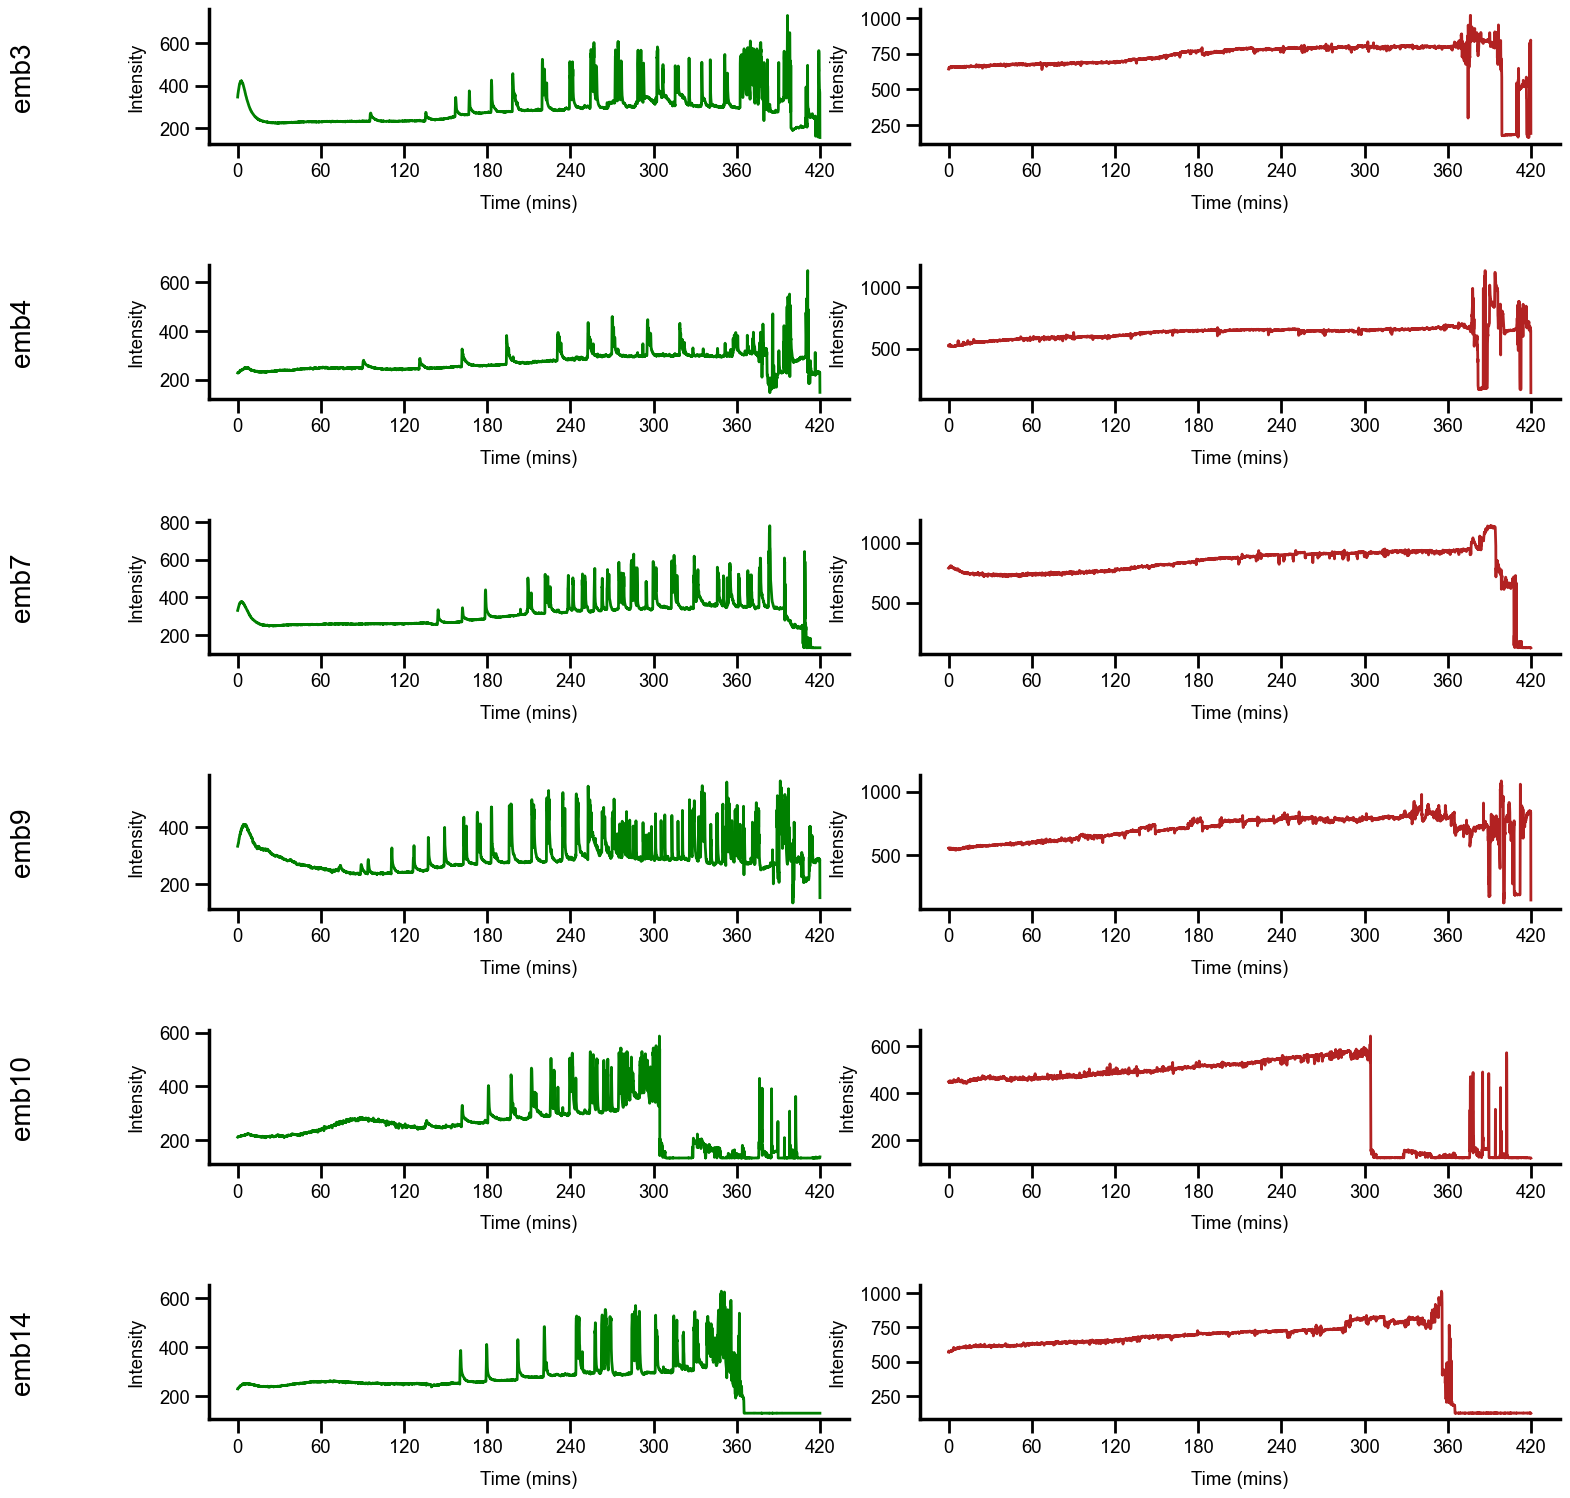

In [81]:
myplots.plot_raw_signals(all_embryos, subplots_rc)

## Plot All DFF Traces

Plots the dff traces for all embryos.

**preprocess_multi_embryos**

optional parameters:
* duration: target number of frames to include
* onset_pad: number of frames to include before onset

**plot_traces**

optional parameters:
* color: line color
* xmin: x-axis minimum in minutes
* xmax: x-axis maximum in minutes
* ymin: y-axis minimum in minutes
* ymax: y-axis maximum in minutes

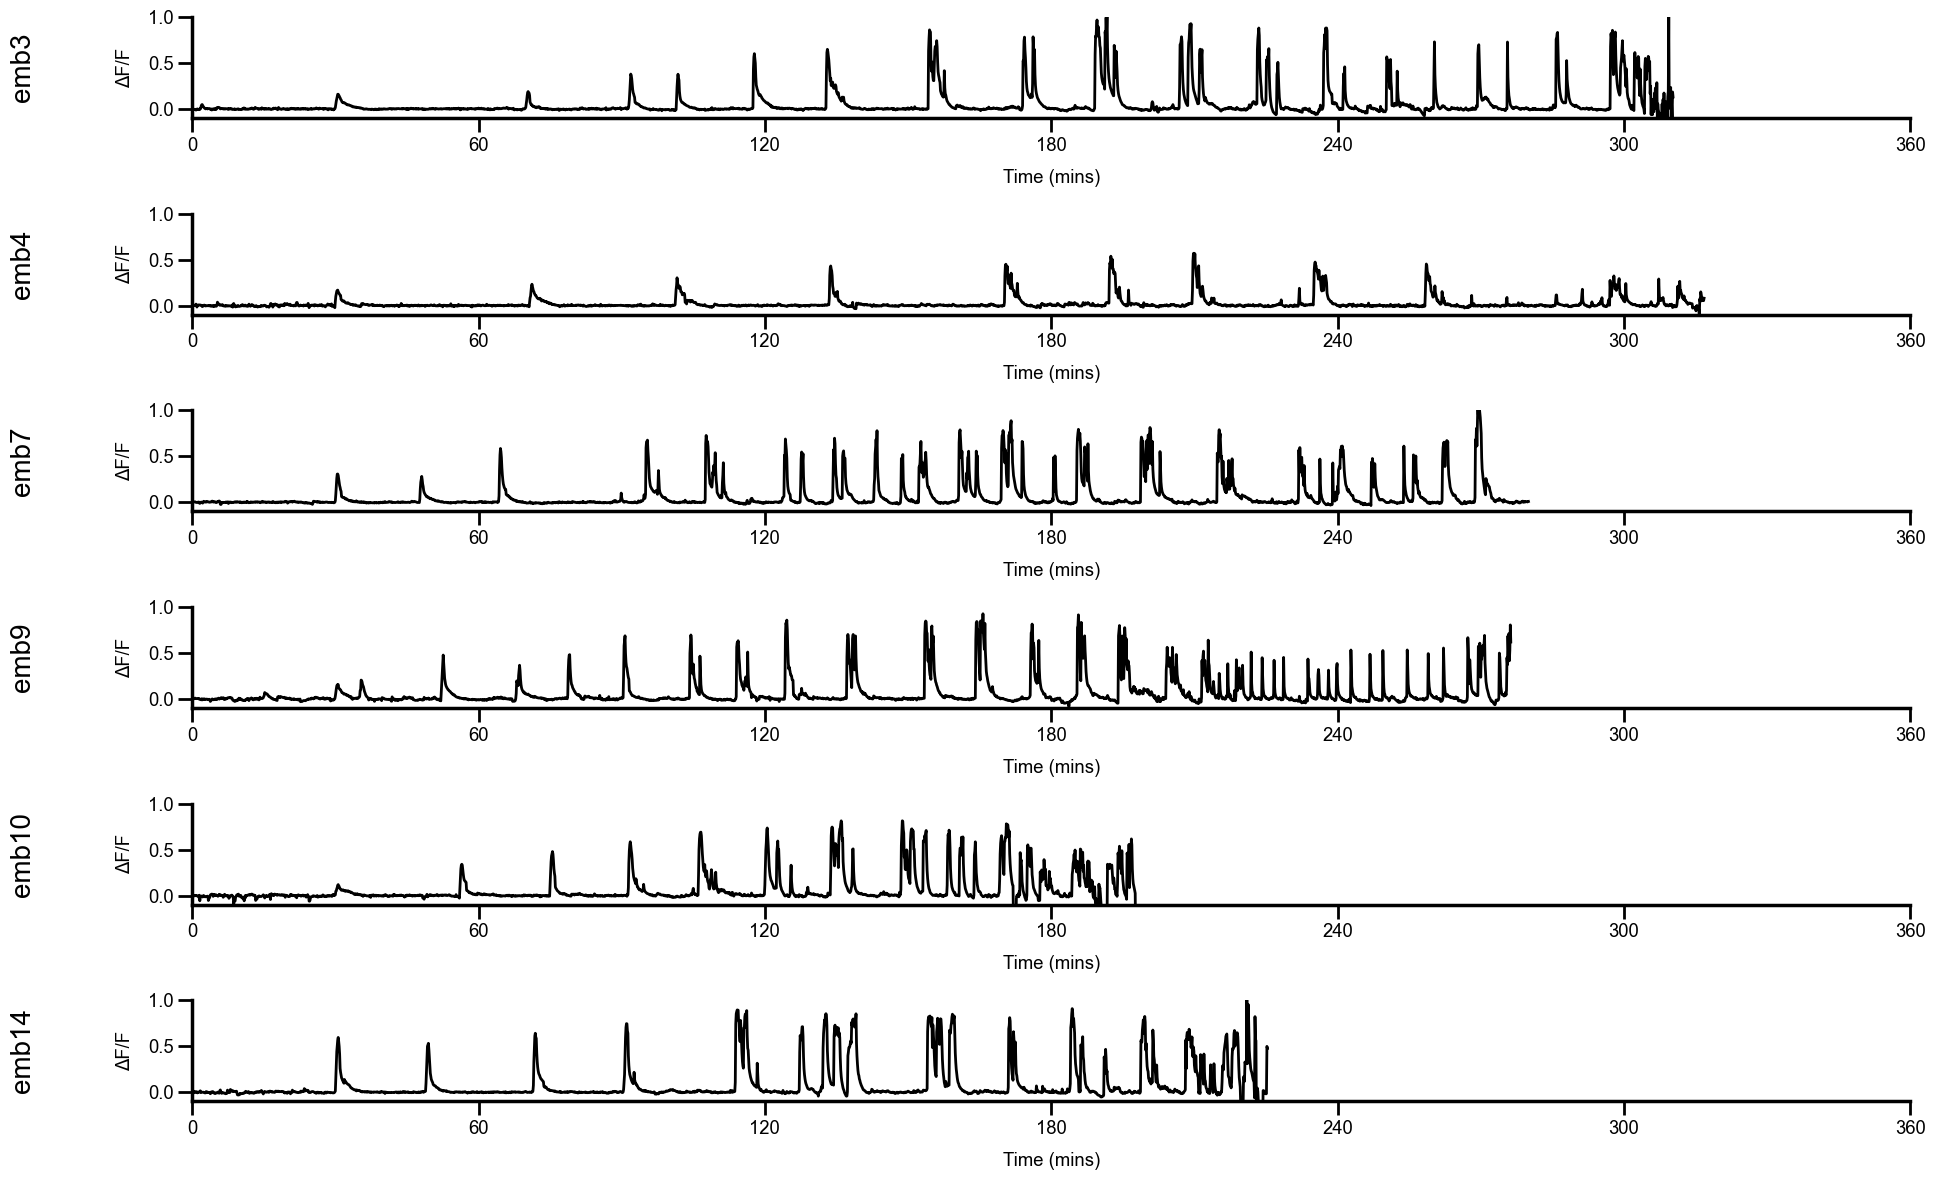

In [82]:
embryo_info = {}

for emb in all_embryos:
    name = emb.name
    time = emb.trace.aligned_time
    dff = emb.trace.aligned_dff
    embryo_info[emb.name] = [time, dff]

myplots.plot_traces(embryo_info, subplots_rc, ymax=1)

## Plot All Spectrograms

Preprocesses all dffs to a standardized length, then plots the magnitude of its STFT over time. The x-axis displays time (columns), y-axis displays frequency (rows), and color displays intensity. 

**preprocess_multi_dffs** 

optional parameters:
* duration: target number of frames to include
* onset_pad: number of frames to include before onset


**calculate_multi_STFTs**

optional parameters:
* fs: sampling rate
* fft_size: num frames in each segment
* noverlap: num frames to overlap between segements

**plot_specs** 

optional parameters:
* display_colorbar: True to display, False to hide
* xmin: x-axis minimum in minutes
* xmax: x-axis maximum in minutes
* ymin: y-axis minimum in minutes
* ymax: y-axis maximum in minutes

In [ ]:
embryo_info = {}

for emb in all_embryos:
    name = emb.name
    dff = emb.trace.aligned_dff
    f, t, Zxx = emb.trace.calculate_STFT(dff)
    embryo_info[name] = [f,t,Zxx]

myplots.plot_specs(embryo_info, mymap, subplots_rc, display_colorbar=False)

TypeError: Image data of dtype complex128 cannot be converted to float

## Plot Average Spectrogram

Preprocesses all dffs to a standardized length, then plots the average magnitude of their STFTs over time. The x-axis displays time (columns), y-axis displays frequency (rows), and color displays intensity. 

**preprocess_multi_dffs** 

optional parameters:
* duration: target number of frames to include
* onset_pad: number of frames to include before onset

**calculate_multi_STFTs**

optional parameters:
* fs: sampling rate
* fft_size: num frames in each segment
* noverlap: num frames to overlap between segements

**plot_spec** 

optional parameters:
* display_colorbar: True to display, False to hide
* xmin: x-axis minimum in minutes
* xmax: x-axis maximum in minutes
* ymin: y-axis minimum in minutes
* ymax: y-axis maximum in minutes

N=6


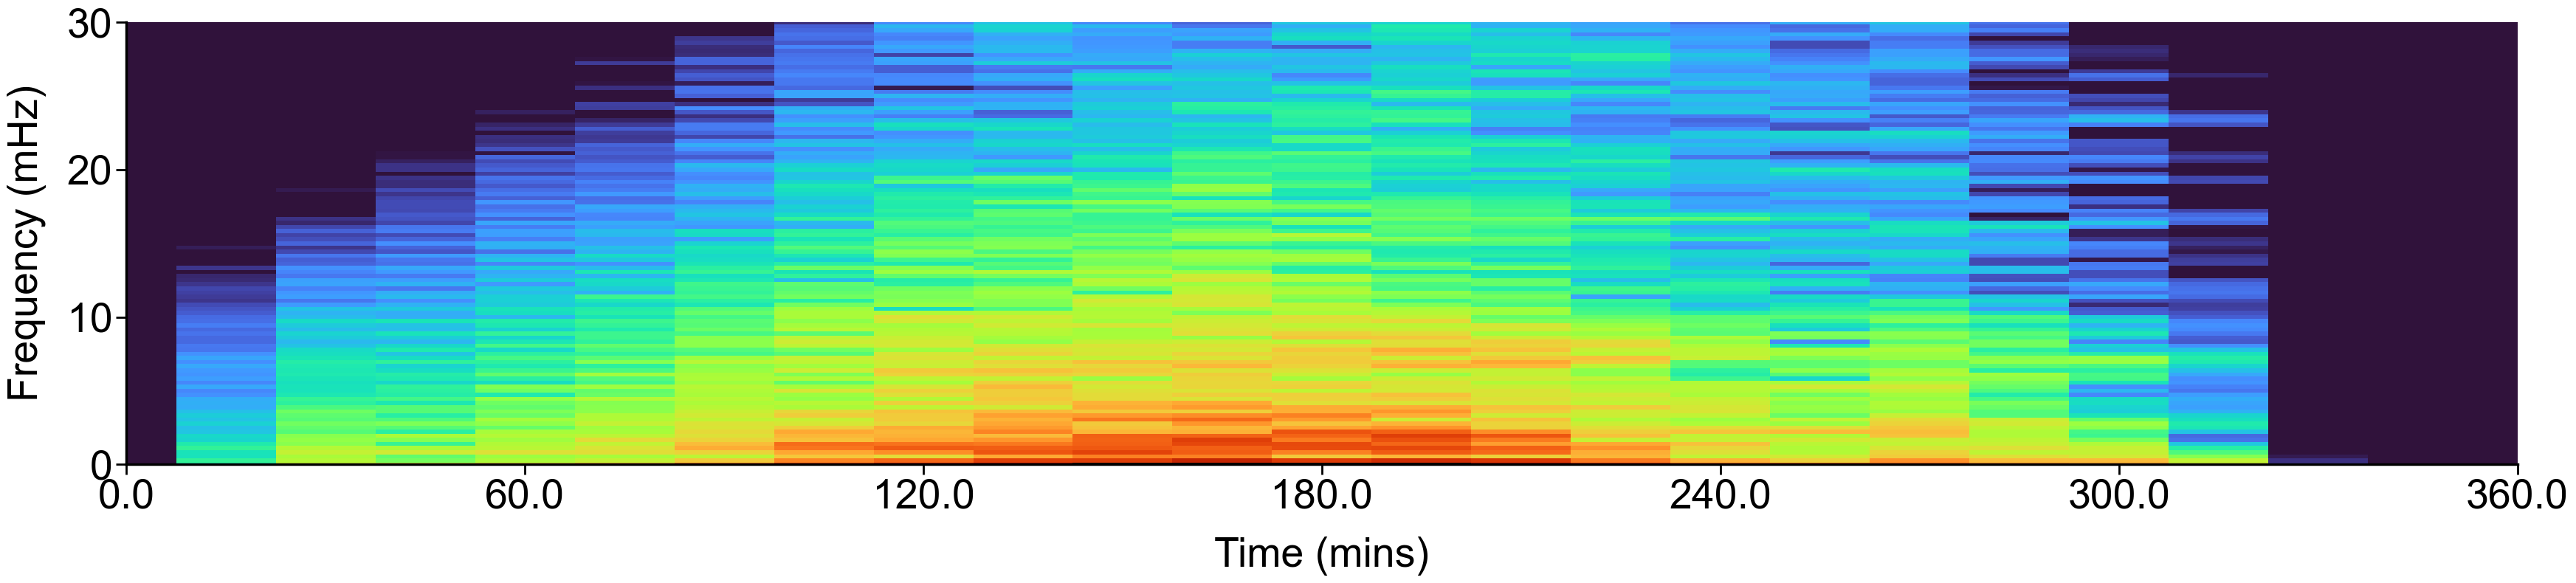

In [ ]:
print(f'N={len(all_embryos)}')

f_all = []
t_all = []
Zxx_all = []

for emb in all_embryos:
    dff = emb.trace.aligned_dff
    f, t, Zxx = emb.trace.calculate_STFT(dff)
    f_all.append(f)
    t_all.append(t)
    Zxx_all.append(Zxx)

stft_magnitudes = np.abs(Zxx_all)
avg_magnitude = np.mean(stft_magnitudes, axis=0)
myplots.plot_spec(f, t, avg_magnitude, mymap, spec_rc, display_colorbar=False)